<h1 style="text-align:center;">🌍 World Happiness Analysis</h1>

<p align="center">


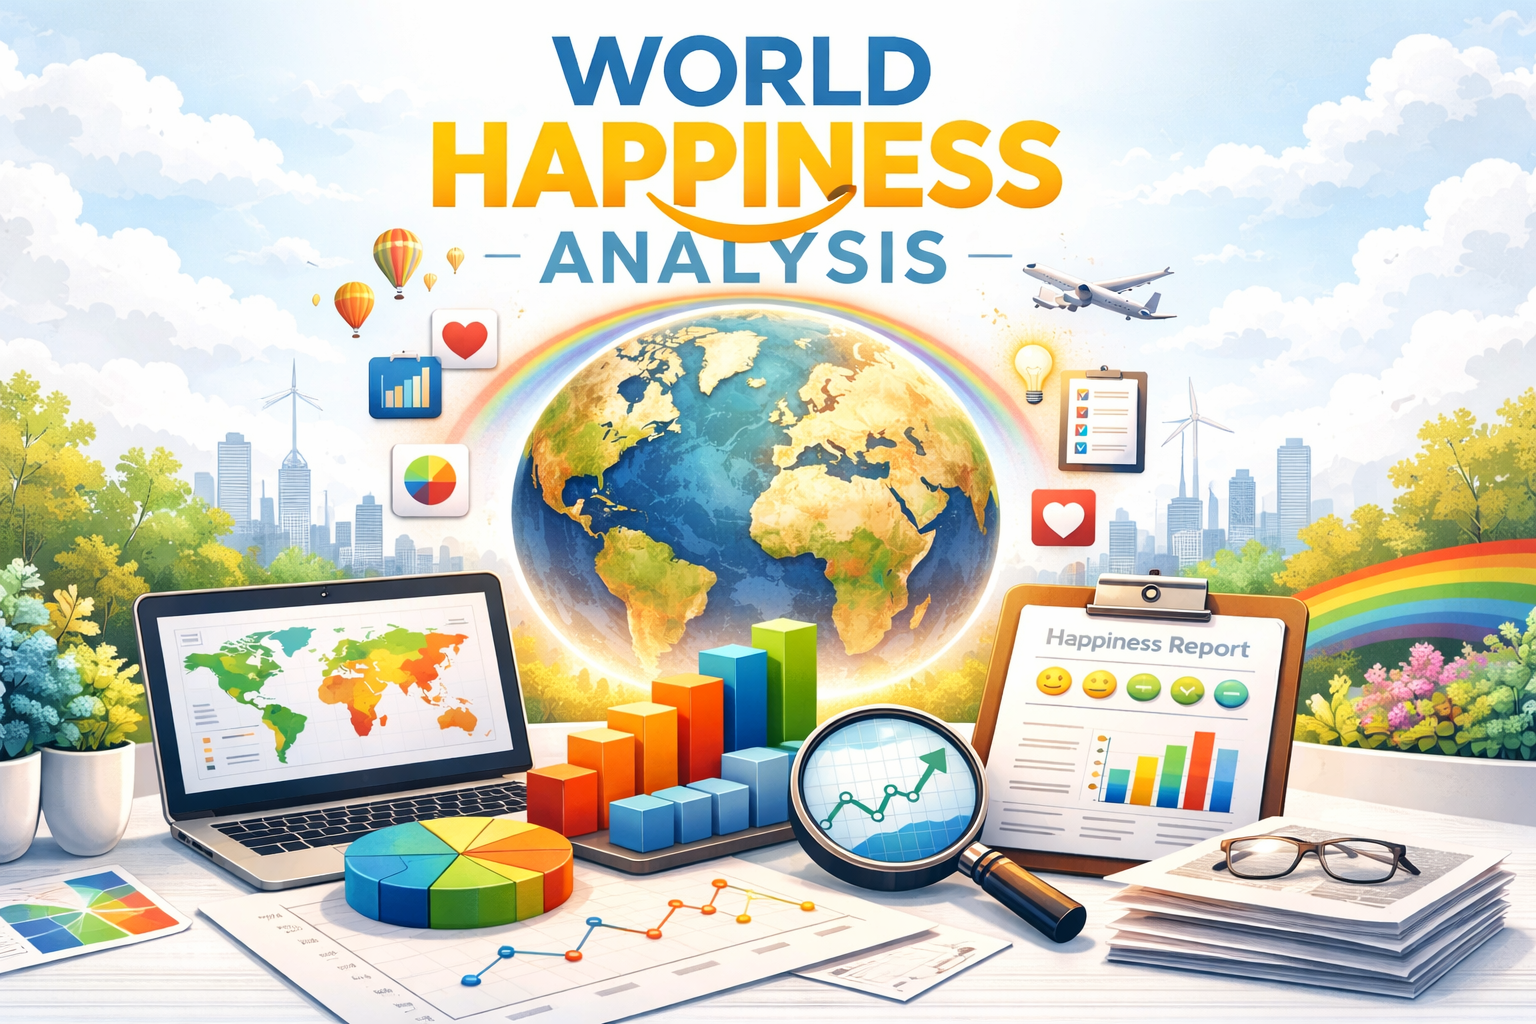



<p align="center">
Analyzing global happiness data to understand the factors influencing well-being across countries.
</p>



# Table of Contents
1. [Introduction](#introduction)
2. [Environment Setup & Data Loading](#Environment-Setup-Data-Loading)
3. [Data Cleaning](#data-cleaning)
4. [Top Performers Analysis](#TopPerformersAnalysis)
5. [Correlation & Economic Drivers](#CorrelationEconomicDrivers)
6. [Time Series Trend Analysis ](#TimeSeriesTrendAnalysis)
7. [Demographics: Population vs. Happiness](#DemographicsPopulationvs.Happiness)
8. [Interactive Geo-Spatial Visualization](#InteractiveGeo-SpatialVisualization)
9. [Final Conclusion & Insights](#Conclusion)



# Introduction:

Global Happiness Analysis <a name="introduction"></a>


##Overview
Happiness is more than just an emotion; it is a measurable reflection of a nation's social and economic health. This project explores the World Happiness Report to understand what makes some countries happier than others and how global well-being has shifted over the last decade.

##Objectives
In this analysis, we aim to answer several key questions:

- **Top Performers:** Which countries consistently rank as the happiest, and what are their common traits?

- **Time Trends:** Has the world become happier over the years, or are we seeing a decline?

- **Economic Impact:** How strong is the correlation between GDP per Capita, Unemployment, and overall happiness?

- **Demographics:** Does a country's Population size significantly affect its happiness score?

##Dataset
The analysis utilizes a CSV dataset (sourced from Kaggle) containing global happiness scores and various social-economic indicators such as Social Support, Freedom, and Life Expectancy.



#Environment Setup & Data Loading <a name="Environment-Setup-Data-Loading"></a>
In this initial phase, we import the necessary libraries for data manipulation (pandas) and visualization (matplotlib, seaborn, plotly). Then, we load the dataset and perform a quick inspection.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Loading the dataset
df = pd.read_csv("/content/world_happiness_report (1).csv")

# Initial Exploration
print("--- Data Info ---")
df.info()
print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4000 non-null   object 
 1   Year                       4000 non-null   int64  
 2   Happiness_Score            4000 non-null   float64
 3   GDP_per_Capita             4000 non-null   float64
 4   Social_Support             4000 non-null   float64
 5   Healthy_Life_Expectancy    4000 non-null   float64
 6   Freedom                    4000 non-null   float64
 7   Generosity                 4000 non-null   float64
 8   Corruption_Perception      4000 non-null   float64
 9   Unemployment_Rate          4000 non-null   float64
 10  Education_Index            4000 non-null   float64
 11  Population                 4000 non-null   int64  
 12  Urbanization_Rate          4000 non-null   float64
 13  Life_Satisfaction          400

,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2014.670750,5.455005,30482.009953,0.505860,67.917605,0.502723,0.143960,0.498920,10.966748,0.750385,...,0.502812,69.976853,40.002648,6.009270,65.176380,5.987325,67.586327,45.526322,0.494105,74.021450
std,5.724075,1.427370,17216.122032,0.286202,10.172091,0.285219,0.200088,0.288866,5.210712,0.144819,...,0.289186,17.128536,11.634987,2.291172,19.981357,1.725363,15.769023,20.300069,0.293191,13.906888
min,2005.000000,3.000000,1009.310000,0.000000,50.000000,0.000000,-0.200000,0.000000,2.000000,0.500000,...,0.000000,40.000000,20.010000,2.010000,30.010000,3.000000,40.010000,10.030000,0.000000,50.000000
25%,2010.000000,4.237500,15425.125000,0.260000,59.177500,0.260000,-0.030000,0.240000,6.450000,0.630000,...,0.260000,55.580000,29.865000,4.040000,48.170000,4.460000,53.910000,27.840000,0.230000,61.867500
50%,2015.000000,5.430000,29991.255000,0.510000,68.015000,0.500000,0.140000,0.500000,10.995000,0.750000,...,0.500000,69.650000,40.015000,6.070000,64.755000,6.020000,68.015000,45.760000,0.490000,74.475000
75%,2020.000000,6.662500,45763.085000,0.750000,76.690000,0.750000,0.310000,0.742500,15.450000,0.880000,...,0.760000,84.582500,50.187500,8.010000,82.652500,7.490000,81.332500,63.197500,0.760000,85.912500
max,2024.000000,8.000000,59980.720000,1.000000,85.000000,1.000000,0.500000,1.000000,19.990000,1.000000,...,1.000000,100.000000,59.970000,10.000000,99.990000,9.000000,94.990000,79.990000,1.000000,98.000000


# Data Cleaning <a name="data-cleaning"></a>

Before analysis, we must ensure the data is reliable. This involves checking for missing values, removing duplicates, and sorting the data chronologically for each country.

In [ ]:
# Checking for Nulls and Duplicates
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
Country                      0
Year                         0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Generosity                   0
Corruption_Perception        0
Unemployment_Rate            0
Education_Index              0
Population                   0
Urbanization_Rate            0
Life_Satisfaction            0
Public_Trust                 0
Mental_Health_Index          0
Income_Inequality            0
Public_Health_Expenditure    0
Climate_Index                0
Work_Life_Balance            0
Internet_Access              0
Crime_Rate                   0
Political_Stability          0
Employment_Rate              0
dtype: int64

Duplicate Rows: 0


In [ ]:
# Sorting data by Country (Alphabetical) and Year (Ascending)
df_sorted = df.sort_values(by=['Country', 'Year'])
df_sorted.head()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
81,Australia,2005,5.59,18384.29,0.91,69.82,0.23,0.25,0.97,13.79,...,0.17,88.60,42.26,2.86,63.91,7.73,78.56,24.80,0.53,70.20
710,Australia,2005,3.33,7140.48,0.88,60.05,0.66,0.19,0.93,10.60,...,0.46,54.28,59.85,9.99,96.26,8.00,80.21,65.35,0.49,51.99
1952,Australia,2005,3.16,47606.95,0.02,53.95,0.18,0.43,0.14,7.64,...,0.72,44.24,24.45,8.60,81.38,5.79,75.85,15.83,0.55,55.23
1970,Australia,2005,6.82,10006.53,0.39,76.62,0.04,0.22,0.24,18.14,...,0.16,90.20,33.80,2.06,79.68,3.97,87.46,70.01,0.76,84.08
2003,Australia,2005,7.29,32596.03,0.05,79.36,0.15,-0.10,0.03,11.19,...,0.16,98.92,56.01,9.13,57.29,5.10,40.35,72.79,0.05,56.37


# Top Performers Analysis <a name="TopPerformersAnalysis"></a>
This section answers the question: Which countries are the happiest? We identify the top 10 happiest countries overall and track the "winner" for each year.

In [ ]:
# Extracting the top 10 happiest countries
top_happy_countries = df.sort_values(by='Happiness_Score', ascending=False).head(10)
display(top_happy_countries)

# Identifying the top-ranked country per year
top_per_year = df.sort_values('Happiness_Score', ascending=False).groupby('Year').head(1).sort_values('Year')
print(top_per_year[['Year', 'Country', 'Happiness_Score']])

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
363,India,2022,8.00,21006.17,0.72,70.54,0.01,0.33,0.48,9.06,...,0.69,82.25,58.01,3.51,85.93,6.20,52.79,29.26,0.42,92.11
3532,Canada,2019,8.00,3123.40,0.05,81.60,0.42,0.44,0.73,2.11,...,0.81,66.59,21.05,7.05,99.91,4.32,56.12,17.65,0.48,84.16
3908,France,2005,7.99,11698.23,0.87,75.60,0.25,0.02,0.88,10.20,...,0.05,47.76,27.83,9.93,69.43,4.98,84.25,60.53,0.61,78.82
2996,France,2010,7.99,20491.10,0.87,51.51,0.33,0.02,0.72,15.48,...,0.02,41.35,36.70,6.75,87.85,7.11,91.71,52.08,0.59,90.17
130,UK,2007,7.99,46090.49,0.35,81.59,0.07,0.21,0.35,8.33,...,0.59,81.21,28.40,2.79,82.27,3.60,56.59,49.51,0.61,58.53
2950,UK,2015,7.99,26741.07,0.66,72.39,0.29,-0.12,0.82,12.79,...,0.63,51.64,39.07,5.13,56.55,7.36,61.13,30.02,0.95,51.74
1203,China,2007,7.99,13689.22,0.75,75.42,0.21,0.47,0.56,11.22,...,0.39,44.46,36.28,6.82,43.06,8.55,86.10,23.04,0.23,67.04
1060,USA,2007,7.99,6940.92,0.48,58.46,0.33,0.35,0.90,4.79,...,0.53,96.68,51.38,9.15,90.90,4.66,42.74,12.26,0.80,69.10
3979,Germany,2017,7.99,55530.02,0.21,79.99,0.18,0.13,0.02,2.91,...,0.86,71.25,29.81,6.30,80.12,7.96,90.89,68.70,0.16,77.44
56,Canada,2007,7.98,57196.99,0.17,69.57,0.42,-0.06,0.82,3.35,...,0.13,83.41,31.19,3.26,94.26,3.82,87.53,35.46,0.37,71.97


      Year       Country  Happiness_Score
3908  2005        France             7.99
3735  2006        Canada             7.97
130   2007            UK             7.99
3133  2008         China             7.94
383   2009  South Africa             7.95
2996  2010        France             7.99
3382  2011            UK             7.98
781   2012        Brazil             7.96
2217  2013        France             7.97
2340  2014        France             7.91
2950  2015            UK             7.99
350   2016         China             7.97
3979  2017       Germany             7.99
2225  2018            UK             7.98
3532  2019        Canada             8.00
3446  2020        Brazil             7.96
3362  2021         India             7.96
363   2022         India             8.00
3438  2023         China             7.98
2633  2024            UK             7.98


# Correlation & Economic Drivers <a name="CorrelationEconomicDrivers"></a>
Here, we analyze the relationship between happiness and external factors like Income (GDP) and Unemployment. We use a Correlation Matrix to see how these variables move together.

In [ ]:
# Defining columns for correlation
cols = ['Happiness_Score', 'GDP_per_Capita', 'Unemployment_Rate', 'Social_Support', 'Freedom']
correlation_matrix = df[cols].corr()

# Calculating the specific correlation between Money and Happiness
correlation = df['Happiness_Score'].corr(df['GDP_per_Capita'])
print(f"Correlation Strength (Income vs. Happiness): {correlation:.2f}")

Correlation Strength (Income vs. Happiness): 0.02


# Time Series Trend Analysis <a name="TimeSeriesTrendAnalysis"></a>
We aggregate the data to find the global average happiness score for each year, allowing us to visualize whether the world is becoming happier or not.

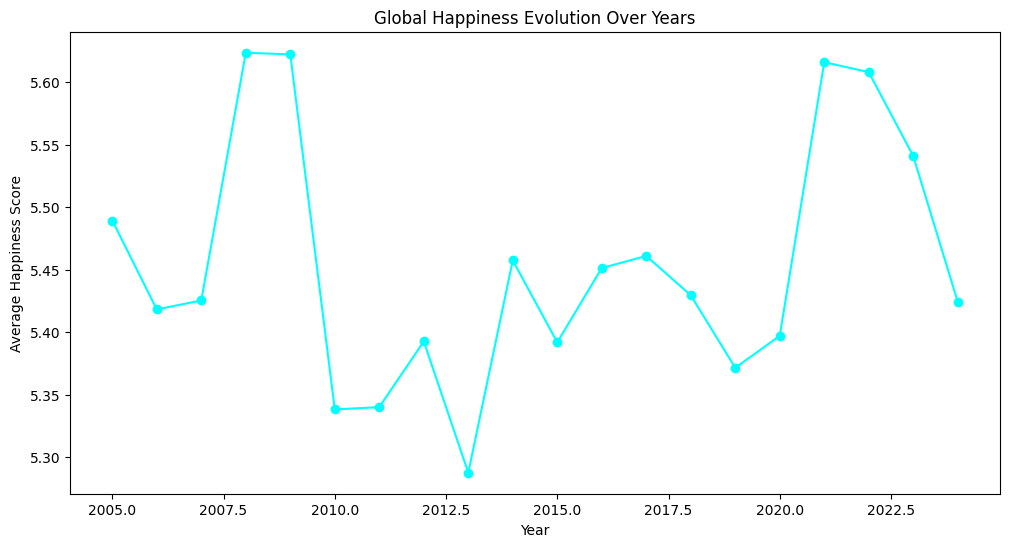

In [ ]:
# Calculating annual global average
yearly_trend = df.groupby('Year')['Happiness_Score'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', color='cyan')
plt.title('Global Happiness Evolution Over Years')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.style.use('dark_background')
plt.show()

# Demographics: Population vs. Happiness <a name="Demographics:Populationvs.Happiness"></a>
This part tests the hypothesis: Does the size of a country's population impact its happiness? We use a regression plot to see the trend.

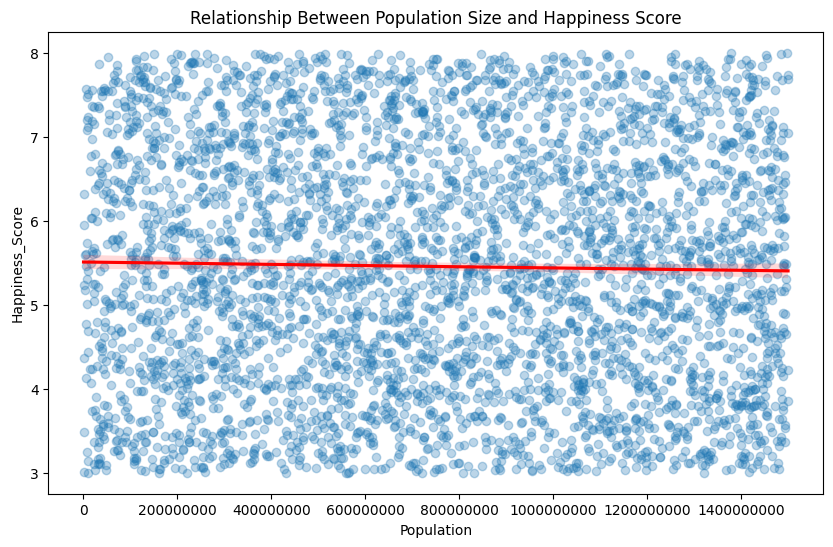

In [ ]:
with plt.style.context('default'):
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x='Population', y='Happiness_Score',
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

    plt.title('Relationship Between Population Size and Happiness Score')
    plt.ticklabel_format(style='plain', axis='x')
    plt.show()

# Interactive Geo-Spatial Visualization <a name="InteractiveGeo-SpatialVisualization"></a>
Using Plotly, we create interactive charts. This includes a global map of happiness and a bubble chart that integrates three dimensions: Income, Happiness, and Population.

In [ ]:
# Global Happiness Choropleth Map
fig_map = px.choropleth(df, locations="Country", locationmode='country names',
                    color="Happiness_Score", title="Global Distribution of Happiness",
                    color_continuous_scale=px.colors.sequential.Plasma)
fig_map.show()

# Bubble Chart: Income vs. Happiness (Size = Population)
fig_bubble = px.scatter(df, x="GDP_per_Capita", y="Happiness_Score",
                  size="Population", color="Country", size_max=30,
                  title="Happiness vs Income (Bubble size = Population)")

fig_bubble.update_layout(template="plotly")
fig_bubble.show()

# Final Conclusion & Insights  <a name="Conclusion"></a>
## Key Findings

After conducting a comprehensive analysis of the World Happiness data, we have reached the following conclusions:

- **The Power of Wealth & Support:** There is a strong positive correlation between GDP per Capita and Happiness Scores. However, economic wealth is not the only driver; Social Support and Freedom play equally crucial roles in sustaining high happiness levels.

- **Population is Not a Barrier:** Our analysis showed that a country’s Population size does not inherently limit or boost its happiness. Small nations (like Finland) and larger ones can both achieve high rankings depending on their internal resource distribution and policies.

- **Global Trends:** Happiness is dynamic. By tracking the Time Series Trend, we observed fluctuations that often correlate with global events, suggesting that collective well-being is sensitive to global stability and economic shifts.

#Recommendations
Based on the data, policymakers should focus not only on increasing GDP but also on strengthening social safety nets and individual freedoms, as these factors show a high impact on the overall "Life Ladder" score.